In [1]:
import numpy as np
from ase.io import read, write
from ase import Atoms
from ase.visualize import view
import subprocess
import os
import time
import matplotlib.pyplot as plt
from ase.geometry import cell_to_cellpar, cellpar_to_cell

At the moment all these codes are meant to be used with POSCAR files

In [36]:
from ase.build import fcc100
from ase.io import write

slab = fcc100('Ag', size=(3, 3, 3), vacuum=15.0, orthogonal=True)
# Shift slab to the bottom (vacuum only on top)
z_positions = slab.get_positions()[:, 2]  # get z-coordinates
min_z = z_positions.min()
slab.positions[:, 2] -= min_z  # move lowest atom to z=0

write('best_worst_harshit/795/POSCAR_Ag100_333', slab, format='vasp') 

### Lattice constant

In [ ]:
# Relaja de manera iterativa un POSCAR, sacando la energía a cada paso, para hallar que a minimiza la Energía
def read_geometry(filepath):
    with open(filepath, 'r') as file:
        lines = file.readlines()
    
    lattice_constant = float(lines[1].strip())
    lattice_vectors = np.array([list(map(float, line.strip().split())) for line in lines[2:5]])
    
    return lattice_constant, lattice_vectors, lines

def write_poscar(filepath, lattice_constant, lattice_vectors, lines):
    lines[1] = f"{lattice_constant:.6f}\n"  # Update lattice constant
    
    with open(filepath, 'w') as file:
        file.writelines(lines)

def submit_sh(directory):
    com = f'qsub sub_VASP.sh {directory}'
    subprocess.run(com, shell=True, env=os.environ)
    
def check_status_qstat():
    qstat_command = 'qstat'
    process = subprocess.run([qstat_command], stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)
    
    if process.returncode != 0:
        print("Error executing qstat:", process.stderr)
        return False

    result = process.stdout.strip().split('\n')
    job_info_lines = result[2:]  # Ignore headers
    
    return len(job_info_lines) > 0

def read_energy_from_oszicar(filepath):
    try:
        with open(filepath, 'r'(POSCAR_path)) as file:
            lines = file.readlines()
            # The energy value is in the last line; the first value is the energy
            energy_line = lines[-1]
            energy = float(energy_line.split()[2])  # Adjust index as necessary
            return energy
    except Exception as e:
        print(f"Error reading energy from {filepath}: {e}")
        return None

def vary_lattice_constant(directory, filename, start, end, step):
    filepath = f"{directory}/{filename}"
    lattice_constant, lattice_vectors, lines = read_poscar(filepath)
    
    current_lattice_constant = start
    energies = []  # List to store energies
    lattice_constants = []  # List to store lattice constants

    try:
        while current_lattice_constant <= end:
            new_filename = "POSCAR"
            new_filepath = f"{directory}/{new_filename}"
            write_poscar(new_filepath, current_lattice_constant, lattice_vectors, lines)
            
            # Submit the job
            submit_sh(directory)
            
            # Wait until qstat is empty
            while True:
                job_statuses = check_status_qstat()
                if not job_statuses:  # If qstat is empty
                    break
                time.sleep(5)  # Wait 5 seconds before checking again
            
            # Read the energy from OSZICAR after the job is done
            oszicar_filepath = f"{directory}/OSZICAR"  # Adjust path as necessary
            energy = read_energy_from_oszicar(oszicar_filepath)
            if energy is not None:
                energies.append(energy)
                lattice_constants.append(current_lattice_constant)
                
                # Save energies and lattice constants periodically
                with open(f"{directory}/energies_vs_lattice_const.txt", 'a') as f:
                    f.write(f"{current_lattice_constant:.6f} {energy:.6f}\n")

            current_lattice_constant += step

    except KeyboardInterrupt:
        print("Process interrupted. Saving current results...")
        with open(f"{directory}/energies_vs_lattice_const.txt", 'a') as f:
            for lc, e in zip(lattice_constants, energies):
                f.write(f"{lc:.6f} {e:.6f}\n")
        print("Results saved. Exiting gracefully.")
        return lattice_constants, energies

    # Final save if the process completed normally
    with open(f"{directory}/energies_vs_lattice_const.txt", 'w') as f:
        for lc, e in zip(lattice_constants, energies):
            f.write(f"{lc:.6f} {e:.6f}\n")

    return lattice_constants, energies

In [ ]:
# SOLO GENERA EL ARCHIVO
directory = "./Cu" ; filename = "POSCAR"
# valores de la constante de red
start = 3.5 ; end = 3.56 ; step = 0.01

vary_lattice_constant(directory, filename, start, end, step)

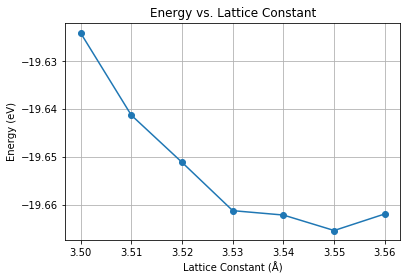

In [4]:
# SOLO HACE EL PLOT
def read_energies_from_file(filepath):
    lattice_constants = []
    energies = []
    try:
        with open(filepath, 'r') as f:
            for line in f:
                lc, energy = map(float, line.split())
                lattice_constants.append(lc)
                energies.append(energy)
    except Exception as e:
        print(f"Error reading from file {filepath}: {e}")
    return lattice_constants, energies

directory = "TOAT_Cu111/slab_11/"
results_filepath = f"{directory}/energies_vs_lattice_const.txt"

# Read data from the file
lattice_constants, energies = read_energies_from_file(results_filepath)

# Plotting the data
plt.plot(lattice_constants, energies, marker='o')
plt.xlabel('Lattice Constant (Å)(POSCAR_path)')
plt.ylabel('Energy (eV)')
plt.title('Energy vs. Lattice Constant')
plt.grid()
# plt.savefig(f"{directory}/energy_vs_lattice_const.png")
plt.show()

# Molecule

# Adsorption Energy

In [4]:
# PARA CALCULAR LA ENERGÍA DE ADSORCIÓN
def read_last_free_energy(OUTCAR_path):

    free_energy = None
    
    with open(OUTCAR_path, 'r') as file:
        for line in file:
            if "TOTEN" in line:
                try:
                    # Split the line and take the second to last value
                    free_energy = float(line.split()[-2])
                except ValueError:
                    continue
    
    if free_energy is None:
        print(f"No se encontró ninguna línea con 'TOTEN' en {OUTCAR_path}.")
        
    return free_energy

def calculate_adsorption_energy(molecule_slab_dir, molecule_dir, slab_dir):

    energies = np.zeros(3)
    
    # Read energies from each OUTCAR file
    energies[0] = read_last_free_energy(molecule_slab_dir + '/OUTCAR')   # Molecule on slab
    energies[1] = read_last_free_energy(molecule_dir + '/OUTCAR')        # Isolated molecule
    energies[2] = read_last_free_energy(slab_dir + '/OUTCAR')            # Isolated slab
    
    # Calculate the adsorption energy
    adsorption_energy = energies[0] - energies[1] - energies[2]
    
    return adsorption_energy

In [5]:
main_dir = 'TOAT_Cu111/'
molecule_slab_dir = main_dir + 'TOAT_on_slab_88_3layers/'
molecule_dir = main_dir + 'TOAT/'
slab_dir = main_dir + 'slab_88_3layers/'
adsorption_energy = calculate_adsorption_energy(molecule_slab_dir, molecule_dir, slab_dir)
print(f'Adsorption energy: {adsorption_energy:.2f} eV')

Adsorption energy: -2.71 eV
